In [2]:
import numpy as np

# Attenuator
The current that reaches the n-Tron gate goes through this RL branch. It converts the raw input current pulse to a much smaller incoming current of same shape as the raw input. 

### Resistor (ex: R5)
In parallel with R4; originates at the same node as R4, since it is so much larger than R4, most of the current is driven to ground; provides attenuation of incoming pulses to the n-Tron gate.
### Inductor (ex: L3)
In series with R5 to make an RL branch off of node A; shapes incoming pulse.

In [3]:
Rd = 10e3 # Ohms
Ld = 5e-9 # Henries

R5 and L3 form a series RL branch also with $V_A(t)$ since in parallel, V is conserved.
Must be solved as an ODE since the lack of impedence matching means there is current going throigh an inductor, making the function of voltate not the closed-form result. Current through R5 is identical to current through L3 since current is the same across all components within a series branch
$$L_3 \cdot \frac{di}{dt} + R_5 \cdot i = V_A(t)$$

In [4]:
from scipy.integrate import solve_ivp
from S01_pulser import pulser1, pulser2
from S02_transmission_line import Td

t = np.linspace(0, 30e-9, 2000)

def attenuator_current(t_array, v_node_func):
    def rhs(t, i): # solve_ivp requires a function of time and current
        V_node = v_node_func(np.array([t]))[0] # 1 element array so np.piecewise definition of t works, and pulsers can be called from N01
        return (V_node - Rd * i[0]) / Ld # equation above

    sol = solve_ivp(rhs, (t_array[0], t_array[-1]), y0=[0.0], 
                     t_eval=t_array, max_step=1e-11) # solver coarsegraining maxed to 10ps to avoid missing motifs
    return sol.y[0]

i_Ld_ch1 = attenuator_current(t, lambda t: pulser1(t - Td))
i_Ld_ch2 = attenuator_current(t, lambda t: pulser2(t - Td))

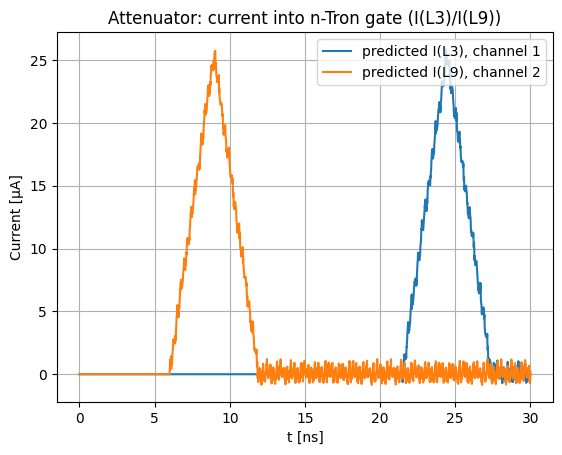

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(t * 1e9, i_Ld_ch1 * 1e6, label="predicted I(L3), channel 1")
ax.plot(t * 1e9, i_Ld_ch2 * 1e6, label="predicted I(L9), channel 2")
ax.set_xlabel("t [ns]")
ax.set_ylabel("Current [µA]")
ax.set_title("Attenuator: current into n-Tron gate (I(L3)/I(L9))")
ax.legend()
ax.grid(True)
plt.show()

Noise: artifact from coarsegraining; never settles
Not taken into account: the n-Tron switching happens midway through the pulse, and causes an interruption in the rise of the current through the gate.